In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/titanic.csv')
df.head()

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,0,1


In [3]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerId  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    str    
 4   sex          891 non-null    int64  
 5   age          891 non-null    float64
 6   sibSp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  cabin        204 non-null    str    
 11  embarked     889 non-null    str    
 12  family_size  891 non-null    int64  
 13  is_alone     891 non-null    int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 97.6 KB


In [28]:
df.columns

Index(['passengerId', 'survived', 'pclass', 'name', 'sex', 'age', 'sibSp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked', 'family_size',
       'is_alone'],
      dtype='str')

In [5]:
df.describe()

,passengerId,survived,pclass,sex,age,sibSp,parch,fare,family_size,is_alone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.136925,2.308642,0.647587,29.361582,0.523008,0.381594,32.204208,0.904602,0.602694
std,257.353842,0.343961,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000
50%,446.000000,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000
75%,668.500000,0.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000,1.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,10.000000,1.000000


In [6]:
print(df['sex'].value_counts())
print(df['embarked'].value_counts())

sex
1    577
0    314
Name: count, dtype: int64
embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [7]:
df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')

pclass,1,2,3
sex,,,
0,0.0,0.0,0.0
1,1.0,0.0,0.0


In [8]:
df.isnull()

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum().sort_values(ascending=False)

cabin          687
embarked         2
pclass           0
name             0
passengerId      0
survived         0
age              0
sex              0
sibSp            0
parch            0
fare             0
ticket           0
family_size      0
is_alone         0
dtype: int64

Text(0.5, 1.0, 'Distribution of Age')

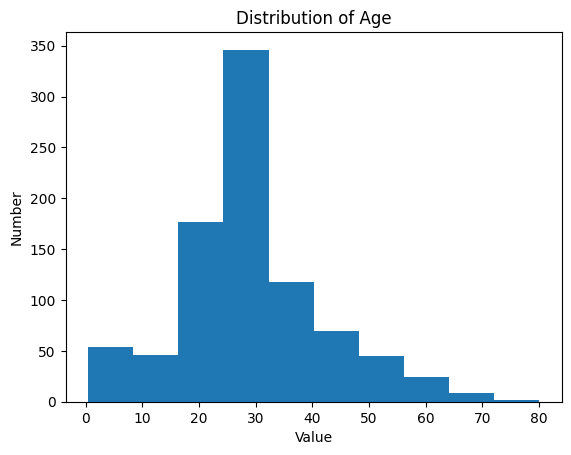

In [10]:
plt.hist(df['age'].dropna())
plt.xlabel('Value')
plt.ylabel('Number')
plt.title('Distribution of Age')

Text(0.5, 1.0, 'Proportion of Each Sex')

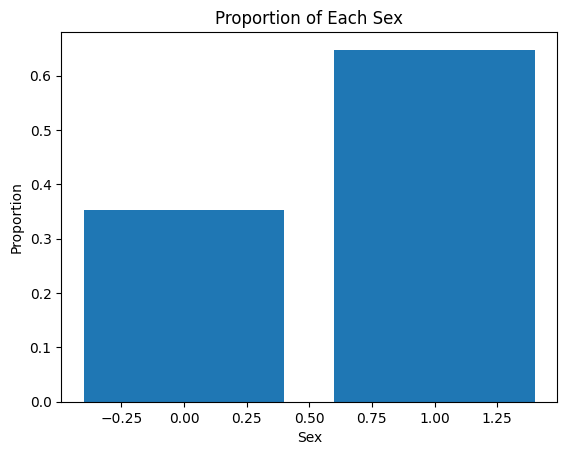

In [11]:
data = df['sex'].value_counts(normalize=True)
plt.bar(data.index, data.values)
plt.xlabel('Sex')
plt.ylabel('Proportion')
plt.title('Proportion of Each Sex')

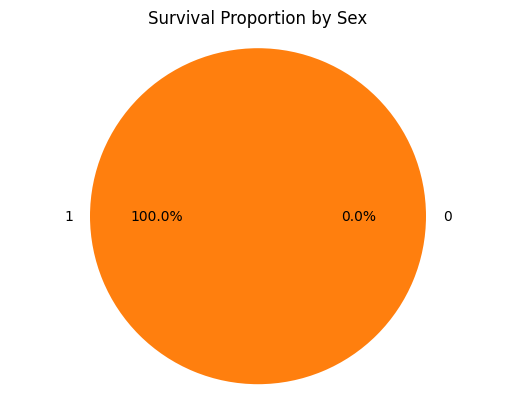

In [12]:
data = df.groupby('sex')['survived'].sum() 
plt.pie(data.values, labels=data.index, autopct='%1.1f%%')
plt.title('Survival Proportion by Sex')
plt.axis('equal')
plt.show()          

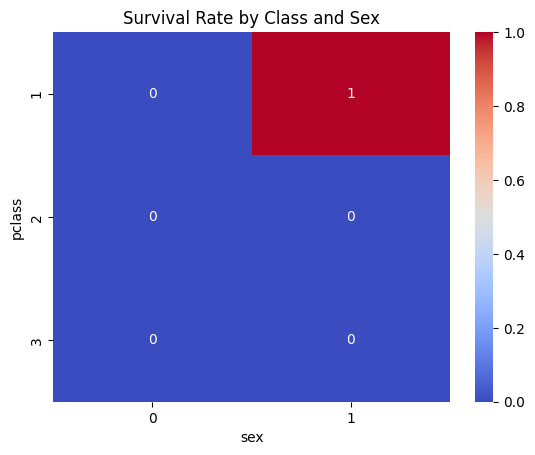

In [13]:
data = df.pivot_table(index='pclass', columns='sex', values='survived')
sns.heatmap(data, annot=True, cmap='coolwarm')
plt.title('Survival Rate by Class and Sex')
plt.show()

In [14]:
df.drop_duplicates()

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,0,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C,0,1


In [15]:
median_val = df['age'].median()
df['age'] = df['age'].fillna(median_val)
df

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,0,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C,0,1


In [16]:
df['sex'] = np.where(df['sex'] == 'male', 1, 0)
df

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,0,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,0,1


In [17]:
all_people = df['passengerId'].max()
surived_people = df['survived'].sum()
survival_protsentage = surived_people / all_people * 100
print(f'Survival Percentage: {survival_protsentage:.2f}%')

Survival Percentage: 13.69%


"\nTepa classlarda tirik qolish ehtimoli yuqori ekanligini ko'rishimiz mumkin.\n"

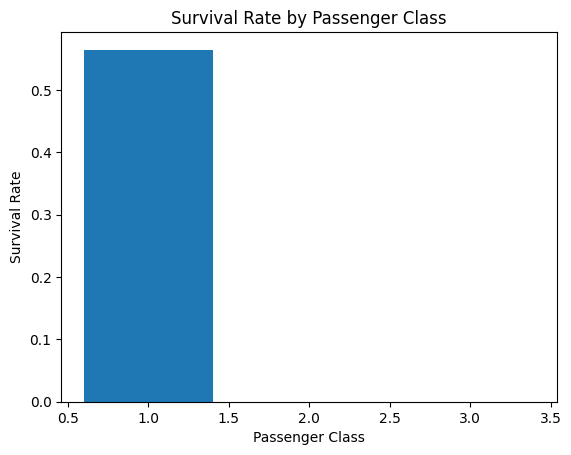

In [18]:
data = df.groupby('pclass')['survived'].mean()
plt.bar(data.index, data.values)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class')

"""
Tepa classlarda tirik qolish ehtimoli yuqori ekanligini ko'rishimiz mumkin.
"""


" \nBu yerda ko'rishimiz mumkinki, yosh bolalar va keksalar tirik qolish ehtimoli yuqori ekanligini ko'rishimiz mumkin.\n"

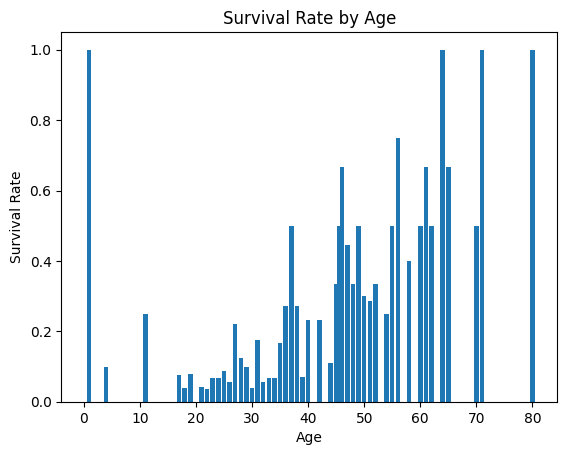

In [19]:
data = df.groupby('age')['survived'].mean()
plt.bar(data.index, data.values)
plt.xlabel('Age')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age')
""" 
Bu yerda ko'rishimiz mumkinki, yosh bolalar va keksalar tirik qolish ehtimoli yuqori ekanligini ko'rishimiz mumkin.
"""

"\nBu yerda ko'rishimiz mumkinki, erkaklar orasida tirik qolish ehtimoli past ekanligini ko'rishimiz mumkin.\n"

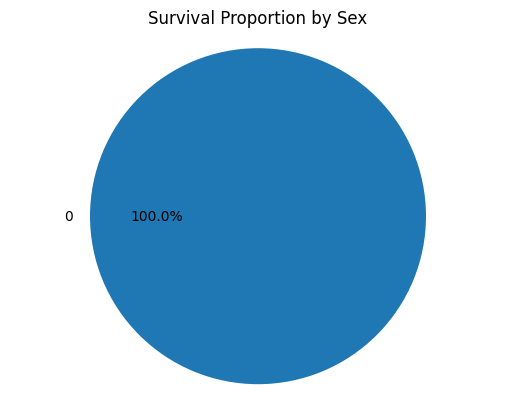

In [20]:
data = df.groupby('sex')['survived'].mean()
plt.pie(data.values, labels=data.index, autopct='%1.1f%%')
plt.title('Survival Proportion by Sex')
plt.axis('equal')

"""
Bu yerda ko'rishimiz mumkinki, erkaklar orasida tirik qolish ehtimoli past ekanligini ko'rishimiz mumkin.
"""

In [21]:
df['family_size'] = df['sibSp'] + df['parch']
df

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,0,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,0,1


In [22]:
df['is_alone'] = np.where(df['family_size'] == 0, 1, 0)
df

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,0,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,0,1


Text(0.5, 1.0, 'Correlation Heatmap')

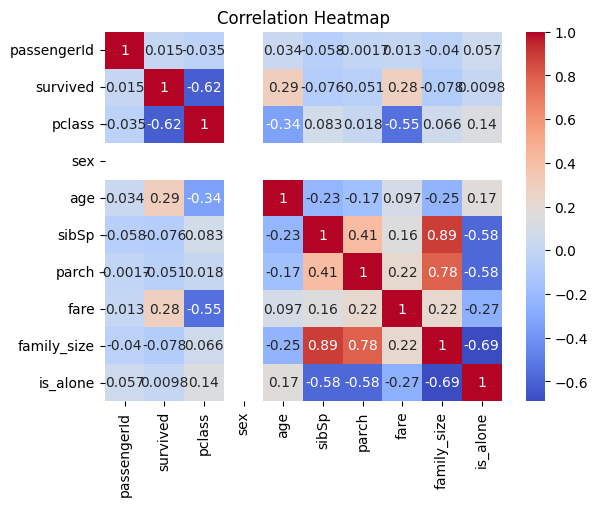

In [23]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

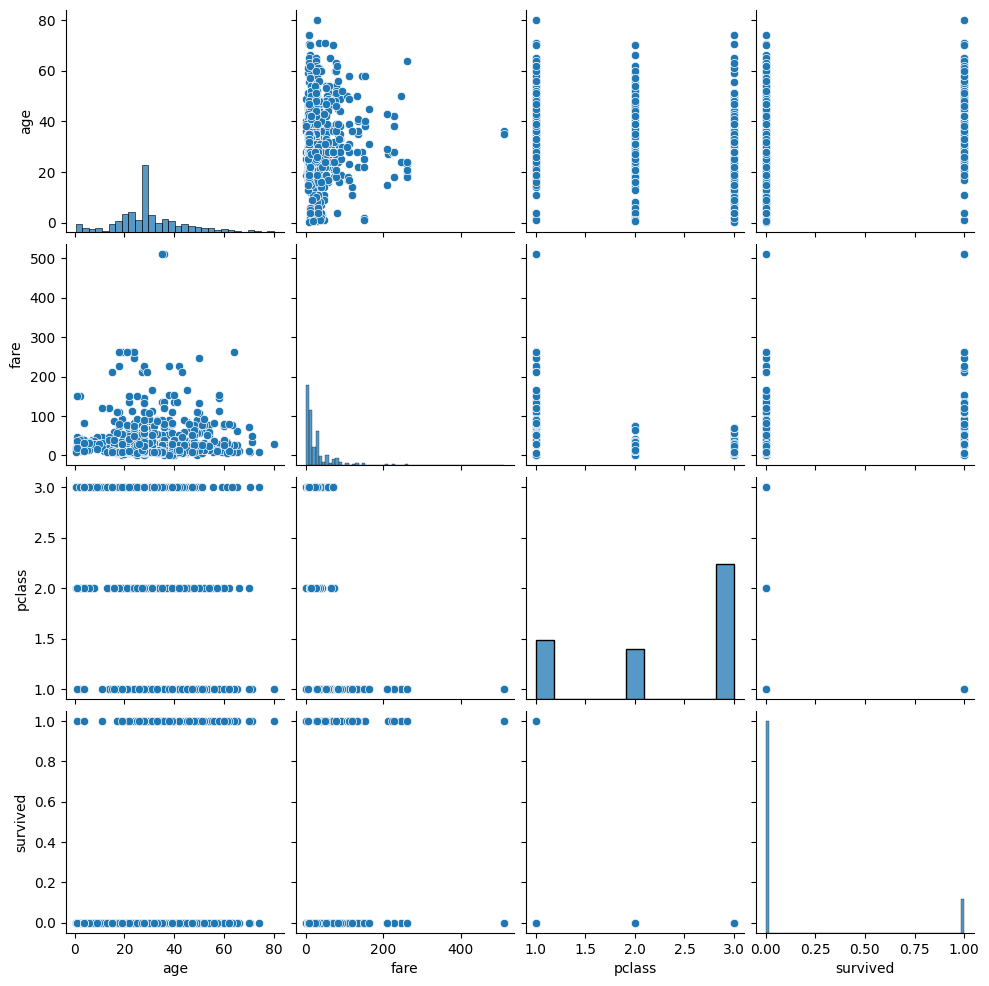

In [24]:
sns.pairplot(df[['age', 'fare', 'pclass', 'survived']])
plt.show()

In [25]:
df['survived'] = np.where((df['pclass'] == 1) & (df['sex'] == 1), 1, 0)
df

,passengerId,survived,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,0,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0
889,890,0,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,0,1


In [26]:
df.to_csv('data/titanic.csv', index=False)